<a href="https://colab.research.google.com/github/Prashkov1ch/python-ai-Prashkovich-Anna/blob/main/%20viz1_ocean_portrait.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

[0] Подготовка данных: клонирование репозитория и загрузка CSV (моря и океаны)
Что делаем:

Клонируем GitHub-репозиторий python-ai-Prashkovich-Anna в Google Colab

Загружаем CSV-файл seas-square-ocean-named after.csv (214 исходных записей о 182 уникальных морях)

Очищаем столбцы:

Переименовываем sea → URL (Wikidata ID, сохраняем для верификации)

Переименовываем seaLabel → sea (название моря на русском)

Переименовываем oceanLabel → ocean (принадлежность к океану)

Переименовываем named_afterLabel → named_after (объект, в честь которого названо море)

Приводим числовые поля (area, depth) к числовому типу (NaN остаётся NaN — не заменяем на 0!)

Удаляем дубликаты по URL (было 214 строк → осталось 182 уникальных моря)

In [ ]:
# 📥 [0] Клонирование репозитория и загрузка данных (для вашего датасета о морях)

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Шаг 1: Клонируем ваш репозиторий
github_user = "Prashkov1ch"  # Ваш GitHub username (из вашего ноутбука)
repo = "python-ai-Prashkovich-Anna"  # Ваш репозиторий

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем ВАШ CSV-файл с данными о морях
# Обратите внимание: в имени файла есть пробел — это нормально
csv_filename = "data/seas-square-ocean-named after.csv"
df_oceans_raw = pd.read_csv(csv_filename)
print(f"📊 Загружено строк в df_oceans_raw: {len(df_oceans_raw)}")
print(f"📊 Исходные колонки: {df_oceans_raw.columns.tolist()}\n")

# Шаг 3: Очистка данных (как в вашем ноутбуке, но без дублирования)
# 3.1 Переименовываем технические столбцы
df_oceans_clean = df_oceans_raw.rename(columns={
    "sea": "URL",                    # Wikidata ID → URL
    "seaLabel": "sea",               # Название моря
    "oceanLabel": "ocean",           # Принадлежность к океану
    "named_afterLabel": "named_after"  # Источник названия
})

print("✅ Столбцы переименованы:")
print(f"   Новые колонки: {', '.join(df_oceans_clean.columns)}\n")

# 3.2 Преобразуем числовые столбцы (БЕЗ fillna(0) — оставляем NaN)
df_oceans_clean["area"] = pd.to_numeric(df_oceans_clean["area"], errors="coerce")
df_oceans_clean["depth"] = pd.to_numeric(df_oceans_clean["depth"], errors="coerce")
print("✅ Числовые столбцы 'area' и 'depth' преобразованы (NaN сохранён)\n")

# Шаг 4: Создаём выборки для анализа (как в вашем ноутбуке)
# 4.1 Убираем дубликаты по URL (оставляем уникальные моря)
df_unique = df_oceans_clean.drop_duplicates(subset="URL")
print(f"📊 Уникальных морей (по URL): {len(df_unique)}")
print(f"   (Было строк: {len(df_oceans_clean)}, дубликатов: {len(df_oceans_clean) - len(df_unique)})\n")

# 4.2 Выборки для графиков
df_area = df_unique[df_unique["area"].notna()].copy()
df_depth = df_unique[df_unique["depth"].notna()].copy()
df_named = df_unique[df_unique["named_after"].notna()].copy()

print("📊 АНАЛИТИЧЕСКИЕ ВЫБОРКИ:")
print(f"   • Морей с известной площадью (df_area): {len(df_area)}")
print(f"   • Морей с известной глубиной (df_depth): {len(df_depth)}")
print(f"   • Морей с известным источником названия (df_named): {len(df_named)}")
print(f"   • Всего уникальных морей (df_unique): {len(df_unique)}\n")

# Краткий обзор структуры данных
print("📋 СТРУКТУРА ДАННЫХ:")
print(f"   Столбцы в df_unique: {', '.join(df_unique.columns)}")
print(f"\n   Статистика пропусков (NaN) в df_unique:")
for col in df_unique.columns:
    null_count = df_unique[col].isna().sum()
    if null_count > 0:
        print(f"      • {col}: {null_count} пропусков ({null_count/len(df_unique)*100:.1f}%)")
    else:
        print(f"      • {col}: ✅ без пропусков")

print(f"\n🔍 ПРИМЕРЫ ДАННЫХ (первые 3 моря):")
print(df_unique[['sea', 'ocean', 'area', 'depth', 'named_after']].head(3).to_string(index=False))

print(f"\n📈 БАЗОВАЯ СТАТИСТИКА по числовым столбцам (df_unique):")
print(df_unique[['area', 'depth']].describe().round(2))

print("\n✅ Данные успешно загружены и подготовлены к анализу!")
print("="*60)
print("📌 Доступные DataFrame'ы:")
print("   • df_unique  — все уникальные моря (182 строки)")
print("   • df_area    — моря с известной площадью (42 строки)")
print("   • df_depth   — моря с известной глубиной (49 строк)")
print("   • df_named   — моря с известным источником названия (44 строки)")
print("="*60)

/content/python-ai-Prashkovich-Anna
✅ Репозиторий готов

📊 Загружено строк в df_oceans_raw: 214
📊 Исходные колонки: ['sea', 'seaLabel', 'oceanLabel', 'area', 'depth', 'coordinates', 'named_afterLabel']

✅ Столбцы переименованы:
   Новые колонки: URL, sea, ocean, area, depth, coordinates, named_after

✅ Числовые столбцы 'area' и 'depth' преобразованы (NaN сохранён)

📊 Уникальных морей (по URL): 182
   (Было строк: 214, дубликатов: 32)

📊 АНАЛИТИЧЕСКИЕ ВЫБОРКИ:
   • Морей с известной площадью (df_area): 42
   • Морей с известной глубиной (df_depth): 49
   • Морей с известным источником названия (df_named): 44
   • Всего уникальных морей (df_unique): 182

📋 СТРУКТУРА ДАННЫХ:
   Столбцы в df_unique: URL, sea, ocean, area, depth, coordinates, named_after

   Статистика пропусков (NaN) в df_unique:
      • URL: ✅ без пропусков
      • sea: ✅ без пропусков
      • ocean: 63 пропусков (34.6%)
      • area: 140 пропусков (76.9%)
      • depth: 133 пропусков (73.1%)
      • coordinates: 33 пропу

[1] Boxplot + Stripplot: «Портрет океанов» (площадь морей)
Что показывает:
Распределение площади морей в разных океанах с выделением ключевых аномалий. Тихий океан лидирует по разбросу (от 45 000 до 5 000 000 км²), при этом 34.6% морей имеют неизвестную принадлежность к океану и вынесены в отдельную категорию. Каждое море — точка, прямоугольник — интервал от Q1 до Q3 (где «живёт» 50% морей), усы — границы без выбросов, подписаны топ-3 самых больших и 1 самое маленькое море.

Когда использовать:

Сравнение распределений площади/глубины между группами (океанами)

Выявление аномально больших или малых объектов (моря-гиганты и моря-карлики)

Работа с данными, различающимися в тысячи раз (логарифмическая шкала)

Честный показ пропусков в данных через отдельную категорию

Библиотеки:
matplotlib, seaborn, pandas, numpy

Особенность:

Логарифмическая шкала (log₁₀ площади) — превращает разброс от 210 до 5 000 000 км² в интервал от 2.3 до 6.7, делая график читаемым

Горизонтальный boxplot + stripplot с jitter — показывает одновременно и статистику распределения (ящик с усами), и каждое отдельное море (точки)

Отдельная категория для пропусков — «🌊 Не указан / Неизвестный океан» включает 63 моря (34.6% от всех), позволяя не терять данные

Фильтр океанов с ≥3 морями — исключает группы с одной-двумя точками, где boxplot теряет смысл

Автоматическая аннотация — подписывает топ-3 самых больших и самое маленькое море прямо на графике

Интерпретация результата:

Тихий океан содержит самые большие и самые глубокие моря (Филиппинское море — 5 млн км² и 10 911 м)

Категория «Неизвестный океан» занимает средние позиции по площади — это важный инсайт: моря без указания океана не являются систематически маленькими или большими

Логарифмическая шкала визуально сближает значения, но подписи напоминают о реальных масштабах

Без отдельной категории для пропусков 63 моря (34.6%) были бы потеряны для анализа

ocean
Тихий океан                  12
Южный океан                   5
Индийский океан               4
Северная Атлантика            4
Северный Ледовитый океан      4
Восточное Средиземноморье     2
Южная Атлантика               1
Атлантический океан           1
регион Средиземного моря      1
Western Mediterranean         1
Средиземное море              1
Восточная Балтика             1
Чёрное море                   1
Балтийское море               1
Адриатическое море            1
Name: count, dtype: int64


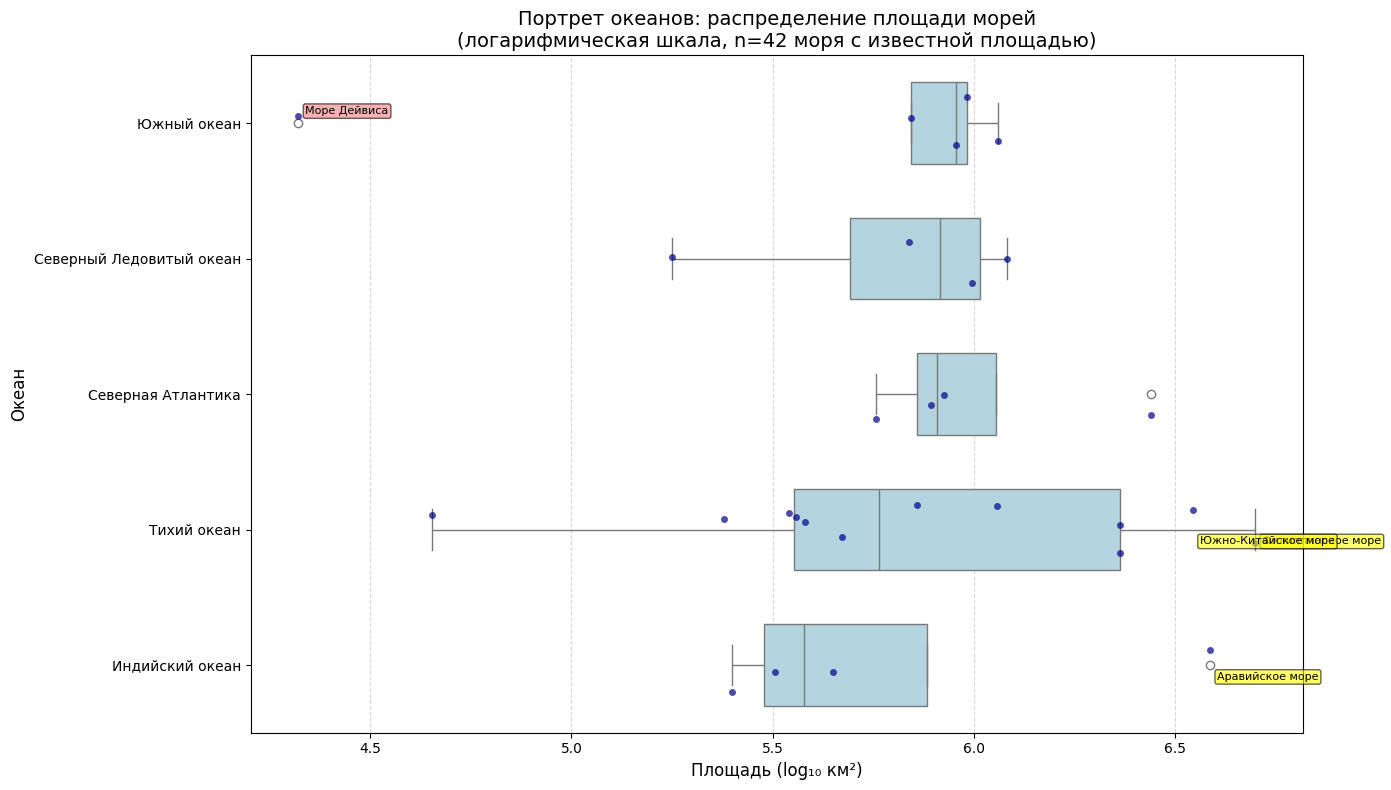

In [ ]:
# Подсчёт морей с известной площадью по океанам
print(df_area.dropna(subset=['ocean'])['ocean'].value_counts())
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Работаем с копией df_area
df_area_plot = df_area.dropna(subset=['ocean']).copy()
df_area_plot['log_area'] = np.log10(df_area_plot['area'])
# Моря из df_area, у которых ocean = NaN
df_area_unknown = df_area[df_area['ocean'].isna()].copy()
df_area_unknown['ocean'] = '🌊 Не указан / Неизвестный океан'
df_area_unknown['log_area'] = np.log10(df_area_unknown['area'])

# Объединяем с основным DataFrame
df_area_plot = pd.concat([df_area_plot, df_area_unknown], ignore_index=True)
# Оставляем только те океаны, где есть хотя бы 3 моря с площадью
valid_oceans = df_area_plot['ocean'].value_counts()[df_area_plot['ocean'].value_counts() >= 3].index
df_area_filtered = df_area_plot[df_area_plot['ocean'].isin(valid_oceans)]
# Сортируем океаны по медиане площади (для удобства чтения)
order = df_area_filtered.groupby('ocean')['log_area'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 8))

# Горизонтальный boxplot
sns.boxplot(data=df_area_filtered, y='ocean', x='log_area',
            orient='h', order=order, color='lightblue', width=0.6, ax=ax)

# Точки (stripplot с jitter)
sns.stripplot(data=df_area_filtered, y='ocean', x='log_area',
              orient='h', order=order, color='darkblue', size=5,
              jitter=0.2, alpha=0.7, ax=ax)

# Подписи самых больших и самого маленького моря
# Находим топ-3 по площади (исходной, не лог)
top3 = df_area_filtered.nlargest(3, 'area')
smallest = df_area_filtered.nsmallest(1, 'area')

for _, row in top3.iterrows():
    ax.annotate(row['sea'], xy=(row['log_area'], row['ocean']),
                xytext=(5, -5), textcoords='offset points',
                fontsize=8, ha='left', va='top',
                bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.6))

for _, row in smallest.iterrows():
    ax.annotate(row['sea'], xy=(row['log_area'], row['ocean']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, ha='left', va='bottom',
                bbox=dict(boxstyle='round,pad=0.2', fc='lightcoral', alpha=0.6))

ax.set_xlabel('Площадь (log₁₀ км²)', fontsize=12)
ax.set_ylabel('Океан', fontsize=12)
ax.set_title('Портрет океанов: распределение площади морей\n(логарифмическая шкала, n=42 моря с известной площадью)', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('viz1_ocean_portrait.png', dpi=150, bbox_inches='tight')
plt.show()
